In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch
torch.cuda.is_available()
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten, Reshape, Rescaling, Conv2D, MaxPooling2D
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train, train_size= 0.8, random_state=1)
print('x_train.shape: ', x_train.shape)
print('y_train.shape: ', y_train.shape)
print('x_test.shape: ', x_test.shape)
print('y_test.shape: ', y_test.shape)
print('x_val: ', x_val.shape)
print('y_val: ', y_val.shape)

x_train.shape:  (48000, 28, 28)
y_train.shape:  (48000,)
x_test.shape:  (10000, 28, 28)
y_test.shape:  (10000,)
x_val:  (12000, 28, 28)
y_val:  (12000,)


In [3]:
# x_train.reshape(28,28,1) # could also use `keras.layers.Reshape

In [4]:
def build_model(activation: str = 'relu') -> Sequential:
  model = Sequential([
    Input(shape=(28,28)),
    Reshape((28,28,1)), 
    Rescaling(1./255), # place every value from 0 to 255 to between 0 and 1
    Conv2D(filters=16, kernel_size=2, activation=activation,strides=(1,1),padding='valid'), # `same` adds padding to match if needed, `valid` leaves the image as is
    Conv2D(16,2,1, "same", None, (1,1), 1, 'relu'),
    MaxPooling2D((2,2)), 

    Conv2D(64,2,1,'same', activation=activation),
    Conv2D(64,2,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(64,2,1,'same', activation=activation),
    Conv2D(64,2,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(64,2,1,'same', activation=activation),
    Conv2D(64,2,1,'same', activation=activation),
    MaxPooling2D((2,2)),
    
    
    Flatten(),
    Dense(128, activation=activation),
    Dense(10, activation='softmax'), #10 categories of dogs
    # Dense(1,activation='linear'), # 1 stock price 
    # Dense(1, activation='sigmoid') # 1 "boolean"
  
  ])


  model.compile(optimizer=Adam(), 
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model


model = build_model()
model.summary()


  

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 27, 27, 16)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,130 (379.41 KB)

 Trainable params: 97,130 (379.41 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.fit(x_train, y_train, batch_size=512, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7122 - loss: 0.8423 - val_accuracy: 0.9287 - val_loss: 0.2315
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9522 - loss: 0.1531 - val_accuracy: 0.9588 - val_loss: 0.1241
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9700 - loss: 0.0938 - val_accuracy: 0.9712 - val_loss: 0.0893
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9762 - loss: 0.0760 - val_accuracy: 0.9760 - val_loss: 0.0782
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9805 - loss: 0.0591 - val_accuracy: 0.9762 - val_loss: 0.0757
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9840 - loss: 0.0507 - val_accuracy: 0.9808 - val_loss: 0.0604
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9865 - loss: 0.0425 - val_accuracy: 0.9814 - val_loss: 0.0598
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9885 - loss: 0.0381 - val_accuracy: 0.9808 - v

In [6]:
sns.kdeplot(np.array(model.layers[-1].weights).ravel())

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
for idx, layer in enumerate(model.layers):
  print(f'{idx}: {layer.name}')

0: reshape_13
1: rescaling_13
2: conv2d_42
3: conv2d_43
4: max_pooling2d_23
5: conv2d_44
6: conv2d_45
7: max_pooling2d_24
8: conv2d_46
9: conv2d_47
10: max_pooling2d_25
11: conv2d_48
12: conv2d_49
13: max_pooling2d_26
14: flatten_3
15: dense_22
16: dense_23


In [12]:
f_map_extractor = Model(inputs=model.inputs, outputs=[model.layers[3].output, model.layers[-1].output, model.layers[7].output])
f_map = f_map_extractor.predict(x_test)
print('f_map[0].shape: ', f_map[0].shape)
print('f_map[1].shape: ', f_map[1].shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
f_map[0].shape:  (10000, 27, 27, 16)
f_map[1].shape:  (10000, 10)


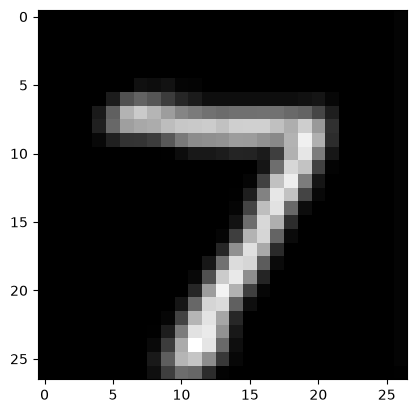

In [17]:
plt.imshow(f_map[0][0][:,:,5], cmap="gray")